## <mark>**92 IMAGES, NO IMPROVEMENTS MADE TO TEXTURE.PY**</mark>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score


## correlation analysis (heatmap)

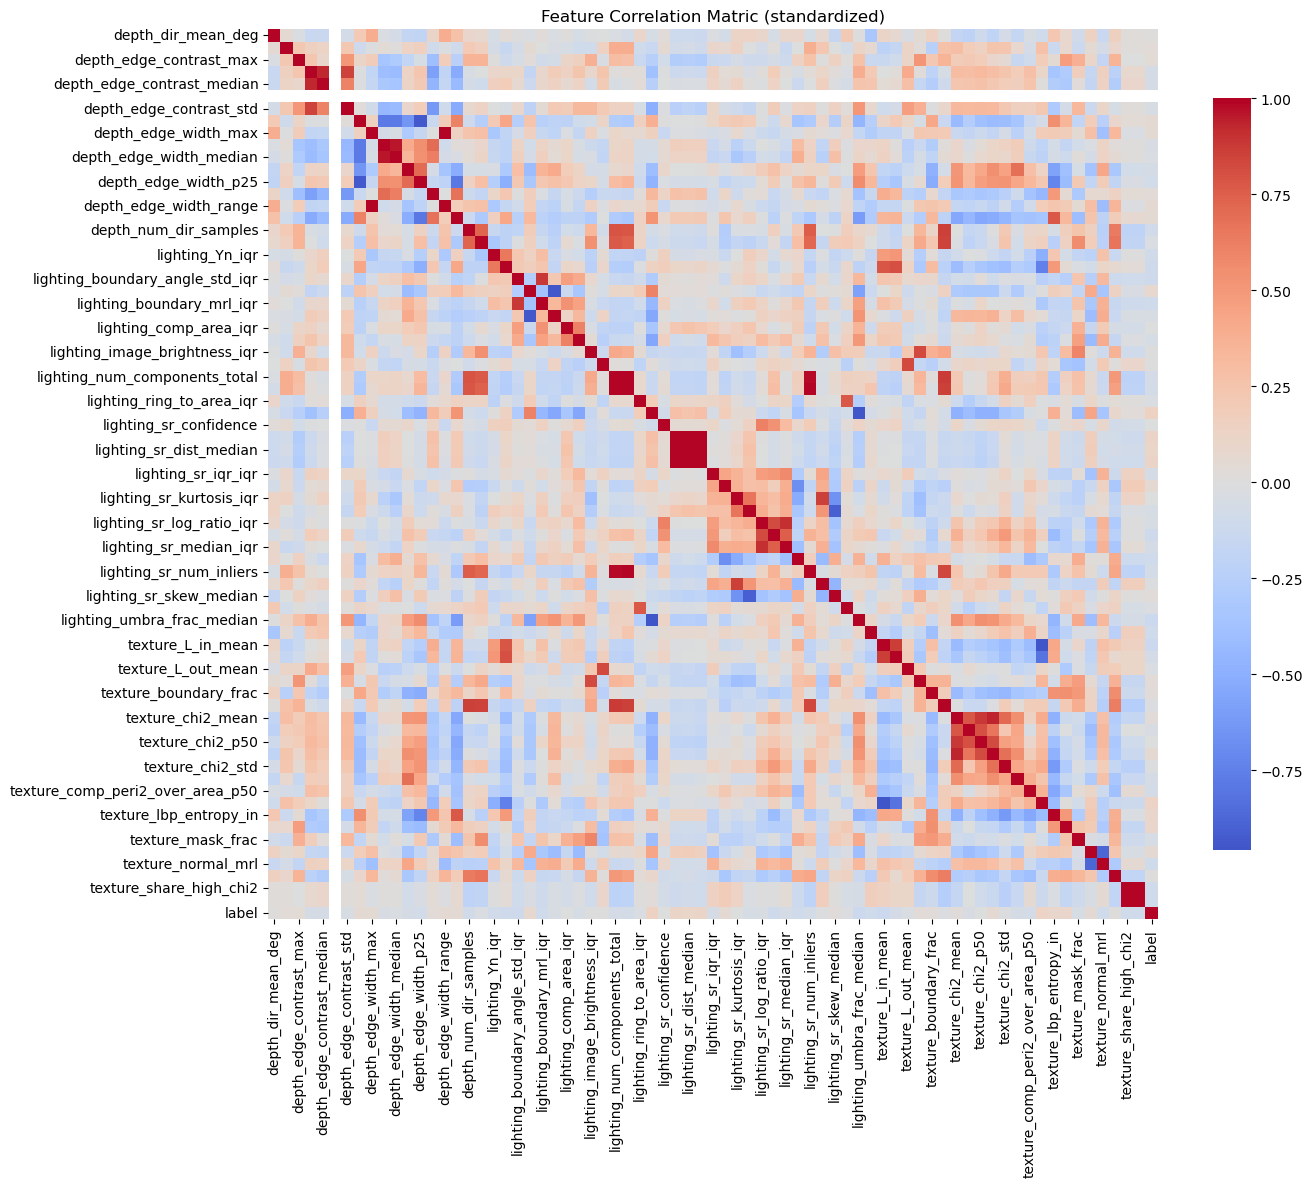


Top correlations with LABEL:

lighting_ring_to_area_median       0.145746
texture_L_in_mean                 -0.130846
texture_contrast_shadow_vs_non     0.130131
lighting_umbra_frac_median        -0.128411
lighting_sr_dist_p75               0.116244
lighting_sr_dist_mean              0.114559
lighting_boundary_angle_std_iqr   -0.107392
lighting_sr_log_ratio_spread      -0.107339
lighting_Yn_median                -0.105761
lighting_sr_dist_median            0.105198
lighting_sr_median_median         -0.100083
texture_share_low_chi2            -0.098281
texture_share_high_chi2           -0.098281
lighting_boundary_mrl_iqr         -0.097891
texture_lbp_entropy_out            0.096520
lighting_usable_frac              -0.095069
texture_normal_mrl                -0.093775
lighting_Yn_iqr                   -0.092928
depth_num_dir_samples             -0.086315
depth_edge_width_p25              -0.083868
Name: label, dtype: float64


In [2]:
# load data
path = "features.csv"

df = pd.read_csv(path)

# keep numeric columns
df_num = df.select_dtypes(include=[np.number])

assert "label" in df_num.columns, "Label column not found"

# standardize features
X = df_num.drop(columns=["label"])
y = df_num["label"]

X_std = (X - X.mean()) / (X.std() + 1e-8)

df_std = X_std.copy()
df_std["label"] = y.values

# correlation matrix
corr = df_std.corr(method="pearson")

# heatmap
plt.figure(figsize=(14,12))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Feature Correlation Matric (standardized)")
plt.tight_layout()
plt.show()

# sorted feature-label correlation
label_corr = corr["label"].drop("label").sort_values(key=np.abs, ascending=False)

print("\nTop correlations with LABEL:\n")
print(label_corr.head(20))

## logistic weights

In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore", message=".*encountered in matmul.*", category=RuntimeWarning)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

# load data
# -----------------------------
CSV_PATH = "features.csv"

df = pd.read_csv(CSV_PATH)
df = df.select_dtypes(include=[np.number])

assert "label" in df.columns, "Label column not found"

X = df.drop(columns=["label"])
y = df["label"].values

feature_names = X.columns.tolist()

# -----------------------------
# standardize features
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Max abs value in X_scaled:", np.max(np.abs(X_scaled)))
print("All finite in X_scaled:", np.isfinite(X_scaled).all())

# -----------------------------
# train logistic regression
# -----------------------------
model = LogisticRegression(
    l1_ratio=1, # this means the penalty used is l1
    solver="liblinear",
    C=0.1,
    max_iter=2000
)

model.fit(X_scaled, y)

# -----------------------------
# extract weights and bias
# -----------------------------
weights = model.coef_[0]
bias = model.intercept_[0]

# combine into table
coef_df = pd.DataFrame({
    "feature": feature_names,
    "weight": weights,
    "abs_weight": np.abs(weights)
}).sort_values("abs_weight", ascending=False)

print("\n==============================")
print("LOGISTIC REGRESSION RESULTS")
print("==============================")
print(f"\nBias (intercept): {bias:.4f}")
print("\nTop 25 Features by |Weight|:\n")
print(coef_df.head(25))

# save full table
coef_df.to_csv("logistic_weights.csv", index=False)

# -----------------------------
# cross-validation accuracy
# -----------------------------
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs = []
fold_num = 1

for train_idx, test_idx in kf.split(X_scaled, y):
    X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    model_cv = LogisticRegression(
        l1_ratio=1,
        solver="liblinear",
        max_iter=1000
    )
    model_cv.fit(X_tr, y_tr)

    w = model_cv.coef_[0]
    b = model_cv.intercept_[0]

    max_abs_w = np.max(np.abs(w))
    print(f"Fold {fold_num}: max|coef| = {max_abs_w:.3e}, intercept = {float(b):.3e}")

    # scores computation MUST be inside the loop
    scores = X_te @ w + b

    print("  scores all finite?", np.isfinite(scores).all(), " min/max:", np.min(scores), np.max(scores))

    # Debug if scores are non-finite
    if not np.isfinite(scores).all():
        print(f"\n!!! Non-finite scores in fold {fold_num} !!!")
        bad_local = np.where(~np.isfinite(scores))[0]
        print("How many bad test rows:", len(bad_local))
        print("First few bad positions (within fold):", bad_local[:10])
        print("Bad score values:", scores[bad_local[:10]])
        print("All finite in X_te:", np.isfinite(X_te).all())

        # Identify which features are non-finite in those bad rows (if any)
        for j in bad_local[:5]:
            row = X_te[j]
            bad_feat_idx = np.where(~np.isfinite(row))[0]
            if len(bad_feat_idx) > 0:
                bad_feats = [feature_names[k] for k in bad_feat_idx[:10]]
                print(f"Bad features for test-row {j}:", bad_feats)

        # Skip this fold so accuracy doesn't crash
        fold_num += 1
        continue

    preds = model_cv.predict(X_te)
    accs.append(accuracy_score(y_te, preds))

    fold_num += 1

print("\n5-Fold Cross-Validation Accuracy:")
print(f"Mean: {np.mean(accs):.4f}")
print(f"Std : {np.std(accs):.4f}")

Max abs value in X_scaled: 9.516273877042964
All finite in X_scaled: True

LOGISTIC REGRESSION RESULTS

Bias (intercept): 0.0000

Top 25 Features by |Weight|:

                          feature  weight  abs_weight
0              depth_dir_mean_deg     0.0         0.0
1               depth_dir_std_deg     0.0         0.0
52             texture_L_out_mean     0.0         0.0
51               texture_L_in_std     0.0         0.0
50              texture_L_in_mean     0.0         0.0
49           lighting_usable_frac     0.0         0.0
48     lighting_umbra_frac_median     0.0         0.0
47        lighting_umbra_frac_iqr     0.0         0.0
46        lighting_sr_skew_median     0.0         0.0
45           lighting_sr_skew_iqr     0.0         0.0
44        lighting_sr_num_inliers     0.0         0.0
43      lighting_sr_median_median     0.0         0.0
42         lighting_sr_median_iqr     0.0         0.0
41   lighting_sr_log_ratio_spread     0.0         0.0
40      lighting_sr_log_ratio_

**NOTE**: use penalty l1 (l1_ratio=1) (lasso regression) to automatically select important features by forcing irrelevant feature coefficients to zero (ideal for sparse data with many irrelevant variables) ; use penalty l2 (l2_ratio=0) (ridge regression) to prevent overfitting when all features are relevant as it shrinks coefficients evenly without setting them to zero.

|   feature    |          l1 (lasso)             |         l2 (ridge)         |
| ------------ | ------------------------------- | -------------------------- | 
| coeff impact | sets some to exactly 0 (sparse) | shrinks to near 0 (dense)  |
| main use     | feature selection               | overfitting prevention     |
| best for     | many irrelevant features        | highly correlated features |

## logistics reduced

In [4]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

CSV_PATH = "features.csv"
df = pd.read_csv(CSV_PATH)

# -----------------------------
# manually select core features
# -----------------------------
selected_features = [

    # depth (hardness + direction)
    "depth_edge_width_median",
    "depth_edge_width_cv",
    "depth_dir_std_deg",
    "depth_num_dir_samples",

    # lighting (strength consistency)
    "lighting_sr_log_ratio_iqr",
    "lighting_sr_dist_median",
    "lighting_Yn_median",
    "lighting_usable_frac",

    # texture (boundary texture + entropy)
    "texture_chi2_mean",
    "texture_chi2_std",
    "texture_lbp_entropy_in",
    "texture_normal_mrl",
    "texture_contrast_shadow_vs_non"
]

df = df[selected_features + ["label"]]

X = df.drop(columns=["label"])
y = df["label"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs = []

for train_idx, test_idx in kf.split(X_scaled, y):
    X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    model = LogisticRegression(
        l1_ratio=1,
        solver="liblinear",
        max_iter=1000
    )

    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    accs.append(accuracy_score(y_te, preds))

print("\nReduced Feature Set CV Accuracy:")
print(f"Mean: {np.mean(accs):.4f}")
print(f"Std : {np.std(accs):.4f}")


Reduced Feature Set CV Accuracy:
Mean: 0.4228
Std : 0.1018


## grouped

In [5]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt 
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier


# silence spurious matmul warnings
warnings.filterwarnings("ignore", message=".*encountered in matmul.*", category=RuntimeWarning)

# -----------------------------
# load data
# -----------------------------
CSV_PATH = "features.csv"

df = pd.read_csv(CSV_PATH)

assert "label" in df.columns, "Label column not found"
assert "filename" in df.columns, "Filename column not found"

# -----------------------------
# build grouping variable (keep pairs together)
# -----------------------------
groups = (
    df["filename"]
    .str.replace("-edited", "", regex=False)
    .str.replace(".jpg", "", regex=False)
)

# -----------------------------
# keep only numeric for modeling
# -----------------------------
df_num = df.select_dtypes(include=[np.number])

X = df_num.drop(columns=["label"])
y = df_num["label"].values

feature_names = X.columns.tolist()

X_all = X.copy()  # keep all features for RandomForest test

# -----------------------------
# TRYING SINGLE FEATURE MODEL
# -----------------------------
X = X[["texture_chi2_p75"]]   # keep only this feature since it is the 
feature_names = ["texture_chi2_p75"]

# -----------------------------
# standardize features
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Max abs value in X_scaled:", np.max(np.abs(X_scaled)))
print("All finite in X_scaled:", np.isfinite(X_scaled).all())

# -----------------------------
# train logistic regression (full dataset)
# -----------------------------
model = LogisticRegression(
    l1_ratio=1,
    solver="liblinear",
    C=0.1,
    max_iter=2000
)

model.fit(X_scaled, y)

# -----------------------------
# extract weights and bias
# -----------------------------
weights = model.coef_[0]
bias = model.intercept_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "weight": weights,
    "abs_weight": np.abs(weights)
}).sort_values("abs_weight", ascending=False)

print("\n==============================")
print("LOGISTIC REGRESSION RESULTS")
print("==============================")
print(f"\nBias (intercept): {bias:.4f}")
print("\nTop 25 Features by |Weight|:\n")
print(coef_df.head(25))

coef_df.to_csv("logistic_weights.csv", index=False)

# -----------------------------
# cross-validation (GroupKFold)
# -----------------------------
gkf = GroupKFold(n_splits=5)
accs = []
fold_num = 1

for train_idx, test_idx in gkf.split(X_scaled, y, groups=groups):

    X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    model_cv = LogisticRegression(
        l1_ratio=1,
        solver="liblinear",
        C=0.1,
        max_iter=2000
    )

    model_cv.fit(X_tr, y_tr)

    w = model_cv.coef_[0]
    b = model_cv.intercept_[0]

    max_abs_w = np.max(np.abs(w))
    print(f"Fold {fold_num}: max|coef| = {max_abs_w:.3e}, intercept = {float(b):.3e}")

    scores = X_te @ w + b
    print("  scores all finite?", np.isfinite(scores).all())

    preds = model_cv.predict(X_te)
    print("  Predicted class balance:", np.mean(preds))
    accs.append(accuracy_score(y_te, preds))

    fold_num += 1

print("\n5-Fold Grouped Cross-Validation Accuracy:")
print(f"Mean: {np.mean(accs):.4f}")
print(f"Std : {np.std(accs):.4f}")
print("Label mean:", np.mean(y))


Max abs value in X_scaled: 3.188053633576214
All finite in X_scaled: True

LOGISTIC REGRESSION RESULTS

Bias (intercept): 0.0000

Top 25 Features by |Weight|:

            feature  weight  abs_weight
0  texture_chi2_p75     0.0         0.0
Fold 1: max|coef| = 0.000e+00, intercept = 0.000e+00
  scores all finite? True
  Predicted class balance: 0.0
Fold 2: max|coef| = 0.000e+00, intercept = 0.000e+00
  scores all finite? True
  Predicted class balance: 0.0
Fold 3: max|coef| = 0.000e+00, intercept = 0.000e+00
  scores all finite? True
  Predicted class balance: 0.0
Fold 4: max|coef| = 0.000e+00, intercept = 0.000e+00
  scores all finite? True
  Predicted class balance: 0.0
Fold 5: max|coef| = 0.000e+00, intercept = 0.000e+00
  scores all finite? True
  Predicted class balance: 0.0

5-Fold Grouped Cross-Validation Accuracy:
Mean: 0.4895
Std : 0.0129
Label mean: 0.5108695652173914



RandomForest 5-Fold Grouped CV Accuracy (ALL features):
Mean: 0.5439
Std : 0.0379

Top RandomForest Features:
lighting_boundary_angle_std_median    0.024305
lighting_sr_kurtosis_median           0.024205
lighting_sr_dist_mean                 0.022989
depth_edge_width_range                0.022786
depth_edge_width_max                  0.022523
depth_dir_mean_deg                    0.020354
lighting_sr_skew_median               0.020197
lighting_sr_dist_median               0.019750
lighting_boundary_angle_std_iqr       0.019449
lighting_sr_median_median             0.019181
texture_chi2_std                      0.018126
lighting_boundary_mrl_median          0.017964
texture_chi2_p25                      0.017869
lighting_sr_median_iqr                0.017693
depth_dir_std_deg                     0.017232
dtype: float64
Random accuracy: 0.45652173913043476

Majority-class baseline accuracy: 0.5108695652173914


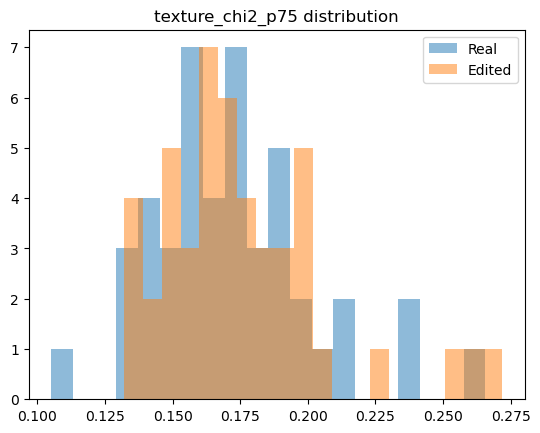

In [6]:
# -----------------------------
# RandomForest (Grouped CV) on ALL features
# -----------------------------
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_accs = []

for train_idx, test_idx in gkf.split(X_all, y, groups=groups):
    X_tr, X_te = X_all.iloc[train_idx], X_all.iloc[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    rf.fit(X_tr, y_tr)
    preds = rf.predict(X_te)
    rf_accs.append(accuracy_score(y_te, preds))

print("\nRandomForest 5-Fold Grouped CV Accuracy (ALL features):")
print(f"Mean: {np.mean(rf_accs):.4f}")
print(f"Std : {np.std(rf_accs):.4f}")

rf.fit(X_all, y)

importances = pd.Series(rf.feature_importances_, index=X_all.columns)
top_rf = importances.sort_values(ascending=False).head(15)

print("\nTop RandomForest Features:")
print(top_rf)

# random guessing baseline
rng = np.random.RandomState(42)
random_preds = rng.randint(0, 2, size=len(y))
print("Random accuracy:", np.mean(random_preds == y))

print("\nMajority-class baseline accuracy:", max((y==0).mean(), (y==1).mean()))

real = X[df_num["label"] == 0]["texture_chi2_p75"]
edited = X[df_num["label"] == 1]["texture_chi2_p75"]

plt.hist(real, bins=20, alpha=0.5, label="Real")
plt.hist(edited, bins=20, alpha=0.5, label="Edited")
plt.legend()
plt.title("texture_chi2_p75 distribution")
plt.show()


The top features (importances) are all almost the same size, which means that there is no strong feature that drives the prediction. Typically for Random Forest, real signal would have values like
0.18
0.12
0.08
0.05
0.03
...

Instead, everything is around 0.02, meaning that the model is not relying on any specific feature. It is making weak shallow splits. This makes sense it the random forest accuracy is only around 0.544, logistic regression is around 0.50 for the single strongest feature, there is heavy histogram overlap, and we have a small dataset of 94 samples.

**IMPORTANT TO NOTE**:
Edits made are local, context dependent, and not necessarily reflected in global statistics that represent the whole image. The extracted features we used are global summaries, texture stats, and lighting aggregates. They don't directly encode object consistency, shadow geometry consistency, edge inconsistencies, and local cloning artifacts. **The model is trying to solve local manipulation problem using global summaries**

**RESULTS**:

Grouped CV:
- logistic (single feature) ≈ **0.51**
- logistic (all features) ≈ **0.46**
- random forest (all features) ≈ **0.544**
- majority baseline ≈ **0.51**

Random forest is ~3-4% above the baseline. This means there is signal in your features, but it's weak, not linearly separable, and not strong.



**NOTE**: The distribution has a heavy overlap and there is no clear separation. Both classes (real and edited) span from about 0.13 to 0.20. The tails (0.23-0.27) contain very few samples.

This means that the strongest feature (texture_chi2_p75) alone does not meaningfully separate real vs edited images. Since this is the strongest feature, it suggests that the current feature set does not contain a strong linear signal for edit detection.

This may be because the edits include object removal, shadow removal, object insertion, shadow insertion, clone stamping, and paint brush with the color picker. These are all local edits, content-dependent, scene-dependent, and not uniform global changes like brightness or contrast shifts.

Our features are mostly global statistics, texture summaries, lighting distributions, and depth summaries, which do not accurately represent the specific edits themselves.

Ex: If you remove a small object from a large image:
- the global histogram barely changes
- texture distributions barely shift
- lighting statistics barely move

So the model doesn't see a consistent pattern across scenes.

**ISSUE**: The features are too global for detecting local manipulations (it is looking at the big picture and missing small, specific edits)

Ex: Model is identifying the overall scene (e.g., "this is a picture of a park") but cannot detected a small, manipulated area (e.g., "a person was airbrushed out of this photo").

*HOW WE CAN FIX*: 
- apply local feature extraction that focuses on specific patches
- implement mechanisms that force the model to focus on specific, high-detail, or anomaly-prone regions rather than averaging over the whole image

## module test

In [7]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

CSV_PATH = "features.csv"
df = pd.read_csv(CSV_PATH)

def test_feature_set(feature_prefix):
    features = [c for c in df.columns if c.startswith(feature_prefix)]
    X = df[features]
    y = df["label"].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X) 

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    accs = []

    for train_idx, test_idx in kf.split(X_scaled, y):
        X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        model = LogisticRegression(
            l1_ratio=1,
            solver="liblinear",
            max_iter=1000
        )
        model.fit(X_tr, y_tr)
        preds = model.predict(X_te)
        accs.append(accuracy_score(y_te, preds))

    print(f"\n{feature_prefix.upper()}ONLY")
    print(f"Features: {len(features)}")
    print(f"Mean Accuracy: {np.mean(accs):.4f}")
    print(f"Std Dev : {np.std(accs):.4f}")

test_feature_set("texture_")
test_feature_set("lighting_")
test_feature_set("depth_")


TEXTURE_ONLY
Features: 22
Mean Accuracy: 0.4222
Std Dev : 0.0772

LIGHTING_ONLY
Features: 32
Mean Accuracy: 0.4444
Std Dev : 0.1296

DEPTH_ONLY
Features: 18
Mean Accuracy: 0.3895
Std Dev : 0.1134


This tells us which shadow characteristic actually works. It tests each module independently and then combinations to measure true signal strength. Tells us which shadow characteristic matters most, whether my physical assumptions hold, and whether to take out entire modules.

The numeric features engineered we engineered are not separating our dataset properly. **Possible causes**: 
- dataset issue (small dataset - shadows may not actually be the manipulation signal, tampering might not involve shadows consistently, real images may have inconsistent lighting naturally)
- shadow mask instability (misses shadows in some images, detects dark objects as shadows, detects noise, fails differently in real vs fake images)
- too much aggregation not enough structure (per shadow distributions -> medians + IQR and per boundary samples -> summary stats *this removes spatial structure and aggregation may wash out manipulation)

## module quality

In [8]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# comparing the performance/quality since accuracy can be unstable is small datasets

CSV_PATH = "features.csv"
df = pd.read_csv(CSV_PATH)

def test_auc(prefix):
    features = [c for c in df.columns if c.startswith(prefix)]
    X = df[features]
    y = df["label"].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    aucs = []

    for train_idx, test_idx in kf.split(X_scaled, y):
        X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        model = LogisticRegression(
            l1_ratio=1,
            solver="liblinear",
            max_iter=1000
        )
        model.fit(X_tr, y_tr)
        # return a matrix line and select the tampered probability
        probs = model.predict_proba(X_te)[:, 1]
        # given the predicted probabilities for tampered images, how well does the model
        # rank real vs tampered (evaluates all possible thresholds)
        aucs.append(roc_auc_score(y_te, probs))

    print(f"\n{prefix.upper()}ONLY")
    print(f"Mean AUC: {np.mean(aucs):.4f}")
    print(f"Std Dev : {np.std(aucs):.4f}")

test_auc("texture_")
test_auc("lighting_")
test_auc("depth_")


TEXTURE_ONLY
Mean AUC: 0.3449
Std Dev : 0.1023

LIGHTING_ONLY
Mean AUC: 0.3543
Std Dev : 0.1003

DEPTH_ONLY
Mean AUC: 0.3291
Std Dev : 0.1360


This quantifies signal strength by measuring AUC (area under ROC curve). Accuracy is threshold-based and unstable in small sets. AUC measures ranking quality. 

The current features are not separating real vs tampered images properly, which is probably because the features are too aggregated to capture local inconsistencies.

The ROC (receiver operating characteristic) curve shows how well a binary classification model performs. It plots the true positive rate (sensitivity) against the false positive rate (1 - specificity) at different threshold settings. It helps identify the optimal balance between detecting true positives and minimizing false alarms.

AUC (area under curve) is a summary metric where 1.0 is perfect and 0.5 is no better than random guessing (50/50).

For AUC, if:
- tampered probabilities tend to be higher -> AUC > 0.5
- they're randomly mixed -> AUC ≈ 0.5
- real probabilities tend to be higher -> AUC < 0.5

roc_auc_score sorts by predicted probability, compares all positive-negative
pairs, and computes how often prob_positive > prob_negative

## check whether label encoding is reversed relative to feature direction

In [9]:
df = pd.read_csv("features.csv")

# flip labels
df["label_flipped"] = 1 - df["label"]

print(df["label"].corr(df["texture_chi2_mean"]))
print(df["label_flipped"].corr(df["texture_chi2_mean"]))

0.021233568880021824
-0.021233568880021824


Flipping labels just flips the sign, which is expected. The magnitude is about 0.02, which is pretty much zero. This means there is no linear relationship between that feature and the label. This makes sense since the AUC results are low. The current shadow-derived numeric features are not predictive of the “tampered” label.